In [6]:
import duckdb
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
files = sorted(Path("/Volumes/travelpassport/tables/allskylitjoin").glob("*.parquet"))

schemas = {}

for file in files:
    schema = duckdb.sql(f"""
        DESCRIBE SELECT * FROM read_parquet('{file}')
    """).fetchall()

    # Convert to a tuple of (column_name, column_type)
    schemas[file.name] = tuple((row[0], row[1]) for row in schema)

# Compare all schemas to the first one
reference_file = files[0].name
reference_schema = schemas[reference_file]

for file, schema in schemas.items():
    if schema != reference_schema:
        print(f"{file} differs from {reference_file}")

In [6]:
schema = duckdb.sql("""

    DESCRIBE SELECT * FROM read_parquet('/Volumes/travelpassport/tables/allskylitjoin/sky_00000065.parquet')

""").df()

In [7]:
schema

,column_name,column_type,null,key,default,extra
0,source_id,BIGINT,YES,None,None,None
1,ra,DOUBLE,YES,None,None,None
2,ra_error,FLOAT,YES,None,None,None
3,dec,DOUBLE,YES,None,None,None
4,dec_error,FLOAT,YES,None,None,None
5,parallax,DOUBLE,YES,None,None,None
6,parallax_error,FLOAT,YES,None,None,None
7,parallax_over_error,FLOAT,YES,None,None,None
8,pm,FLOAT,YES,None,None,None
9,pmra,DOUBLE,YES,None,None,None


In [7]:
df = pd.read_csv("../data/clu_params.csv")
hclu = pd.read_csv("/Volumes/travelpassport/litclusterdatabases/HR24/HR24_clusters.csv")

In [9]:
hclu = hclu.loc[hclu.Name.isin(df.name)].reset_index(drop=True)

<Axes: >

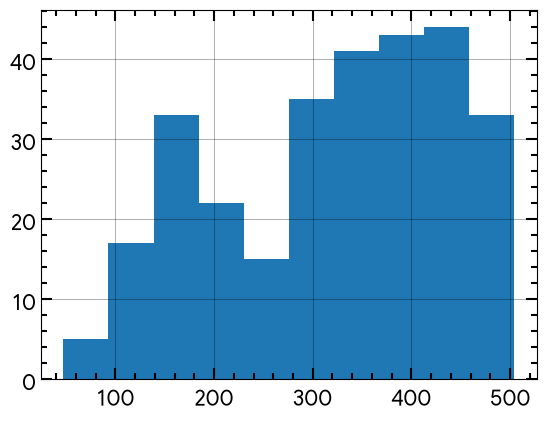

In [11]:
hclu.dist84.hist()

In [13]:
hclu[["dist16", "dist50", "dist84"]].describe()

,dist16,dist50,dist84
count,288.000000,288.000000,288.000000
mean,320.175084,320.473487,320.772675
std,116.951268,117.132632,117.316077
min,47.186006,47.190660,47.195313
25%,213.906113,213.993592,214.081142
50%,340.860047,341.151717,341.443890
75%,416.994508,417.496133,417.977890
max,499.310596,500.014240,504.425351


In [14]:
700 - 504.4

195.60000000000002

In [15]:
700 - 504.425351

195.57464900000002

In [16]:
df

,name,ra,dec,median_member_parallax,pmra,pmdec,median_member_rv,x,y,z,u,v,w,l,b
0,ASCC_19,81.978130,-1.856022,2.802028,1.167717,-1.182478,19.032584,-305.642985,-141.155595,-118.422773,-15.409389,-10.086515,-5.563905,204.788986,-19.379515
1,ASCC_20,82.193554,1.721304,2.748120,-0.569095,0.758990,29.782133,-322.742649,-127.719115,-109.258188,-26.950594,-8.921045,-9.150612,201.590217,-17.472899
2,ASCC_21,82.212040,3.606585,2.895447,1.532353,-0.576284,16.205635,-311.359136,-112.605038,-98.264337,-14.366509,-7.388691,-2.969431,199.882851,-16.530112
3,ASCC_58,153.705592,-55.020312,2.091759,-13.301967,2.760100,10.604105,96.962528,-468.011539,10.535171,-25.653919,-16.406542,-11.534263,281.704930,1.262732
4,ASCC_99,282.171819,-18.384065,3.318956,5.247453,-1.307125,-30.593239,286.789492,83.132683,-40.276022,-30.540943,-7.164767,-3.394549,16.165475,-7.681971
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,UPK_624,254.377125,-60.518748,3.139186,-1.715284,-14.384415,2.912461,268.359647,-160.843387,-59.909075,-9.031849,-16.583242,-11.421553,329.063316,-10.839924
284,UPK_626,239.790501,-50.418343,1.958847,-7.464229,-5.604410,-18.061477,444.876851,-249.730218,18.282266,-26.819149,-10.795865,0.804036,330.692461,2.052324
285,UPK_640,249.692390,-39.507143,5.690132,-11.882454,-21.390537,0.788147,167.747697,-50.200318,15.039678,-4.589213,-19.396684,-4.347077,343.339617,4.909248
286,ZHBJZ_1,103.946607,-5.791223,3.489019,-7.318017,-2.444787,20.970204,-223.954955,-178.665642,-8.372300,-17.129771,-11.654070,-10.972568,218.581987,-1.673911
